# variable8: 기차역까지의 거리 계산

수업자료 범위 수정: API/거리 계산 핵심 기능 유지, matplotlib는 수업자료 범위(plt.plot)로 대체

In [1]:
# 라이브러리 임포트

import requests
import pandas as pd
import numpy as np
import time
from math import radians, cos, sin, asin, sqrt
import matplotlib.pyplot as plt


In [2]:
# 설정값

KAKAO_API_KEY = "535c6e3c45e29358987222e3a1e4af76"
NEW_COL       = "기차역까지의거리"
NEW_COL_NAME  = "기차역이름"
API_SLEEP     = 0.1

INPUT_PATH = "new_city.csv" # 변수 추출하고자 하는 csv 파일명을 입력
ENCODING   = "utf-8-sig"

In [3]:
# 기존 컬럼 초기화

df = pd.read_csv("new_city.csv", encoding='utf-8-sig', dtype=str) # 변수 추출하고자 하는 csv 파일명을 입력
df = df.drop(columns=['기차역까지의거리', '기차역이름'], errors='ignore')
df.to_csv("new_city.csv", index=False, encoding='utf-8-sig') # 변수 추출하고자 하는 csv 파일명을 입력
print("완료")


완료


In [4]:
# 기차역 좌표 목록

TRAIN_STATIONS = {
    "서울역":     (37.5547, 126.9707),
    "용산역":     (37.5298, 126.9647),
    "광명역":     (37.4213, 126.8650),
    "영등포역":   (37.5155, 126.9069),
    "수원역":     (37.2663, 127.0027),
    "청량리역":   (37.5802, 127.0474),
    "천안아산역": (36.7951, 127.1046),
    "동탄역":     (37.2010, 127.0759),
    "평택지제역": (36.9869, 127.0862),
    "인천역":     (37.4744, 126.6163),
    "안양역":     (37.3943, 126.9562),
}

In [5]:
# 유틸리티 함수 (거리 계산/API - 핵심 기능)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))


def address_to_coords(address, api_key):
    url     = "https://dapi.kakao.com/v2/local/search/address.json"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    params  = {"query": address, "analyze_type": "similar"}
    try:
        resp = requests.get(url, headers=headers, params=params, timeout=5)
        resp.raise_for_status()
        docs = resp.json().get("documents", [])
        if docs:
            return float(docs[0]["y"]), float(docs[0]["x"])
    except Exception as e:
        print(f"  [좌표 변환 오류] {address}: {e}")
    return None


def calc_nearest_train(lat, lon):
    best_name = None
    best_dist = float("inf")
    for name, (slat, slon) in TRAIN_STATIONS.items():
        dist = haversine_km(lat, lon, slat, slon)
        if dist < best_dist:
            best_dist = dist
            best_name = name
    return best_name, round(best_dist, 4)


In [6]:
# 좌표 변환 폴백 함수
# 아래 네 곳은 카카오 API로 좌표변환이 어려워 직접 좌표값을 넣음.

MANUAL_COORDS = {
    "청라한양수자인":                (37.5269691, 126.621144),
    "청라디이스트":                  (37.5274766, 126.6234658),
    "청라모아미래도":                (37.5385249, 126.6206428),
    "청라국제업무단지센텀대광로제비앙": (37.5380479, 126.6230073),
}


def get_coords_with_fallback(row, api_key):
    sigungu = str(row['시군구']).strip()
    dorname = str(row['도로명']).strip()
    aptname = str(row['단지명']).strip()

    if aptname in MANUAL_COORDS:
        return MANUAL_COORDS[aptname], '수동입력'

    coords = address_to_coords(f"{sigungu} {dorname}", api_key)
    if coords:
        return coords, '도로명'

    coords = address_to_coords(f"{sigungu} {aptname}", api_key)
    if coords:
        return coords, '단지명'

    clean_name = aptname.split('(')[0].strip()
    coords = address_to_coords(f"{sigungu} {clean_name}", api_key)
    if coords:
        return coords, '단지명(괄호제거)'

    return None, None


In [7]:
# 메인 처리 함수

def add_train_distance(input_path, api_key, encoding=ENCODING):
    df = pd.read_csv(input_path, encoding=encoding)
    print(f"파일: {input_path}")
    print(f"전체 행: {len(df)}행 / 컬럼: {list(df.columns)}")

    if NEW_COL in df.columns:
        print(f"\n'{NEW_COL}' 컬럼이 이미 존재합니다. 건너뜁니다.")
        return df

    unique_complexes = df[['단지명', '시군구', '도로명']].drop_duplicates(subset='단지명').reset_index(drop=True)
    print(f"\n고유 단지 수: {len(unique_complexes)}개")

    cache_dist = {}
    cache_name = {}

    for i, row in unique_complexes.iterrows():
        apt_name = row['단지명']
        print(f"  [{i+1}/{len(unique_complexes)}] {apt_name}")

        coords, method = get_coords_with_fallback(row, api_key)
        time.sleep(API_SLEEP)

        if coords is None:
            print(f"    → 3차 시도 모두 실패")
            cache_dist[apt_name] = np.nan
            cache_name[apt_name] = np.nan
            continue

        lat, lon = coords
        station_name, dist_km = calc_nearest_train(lat, lon)
        print(f"    → [{method}] 가장 가까운 기차역: {station_name} ({dist_km} km)")

        cache_dist[apt_name] = dist_km
        cache_name[apt_name] = station_name

    df[NEW_COL]      = df['단지명'].map(cache_dist)
    df[NEW_COL_NAME] = df['단지명'].map(cache_name)

    df.to_csv(input_path, index=False, encoding=encoding)
    print(f"\n저장 완료: {input_path}")
    print(f"\n===== {NEW_COL} 요약 통계 =====")
    print(df[NEW_COL].describe())
    return df


In [8]:
# 분포 시각화

def plot_distribution(df):
    if NEW_COL not in df.columns:
        print("기차역까지의거리 컬럼이 없습니다.")
        return

    dist_data = df[NEW_COL].dropna().sort_values().reset_index(drop=True)
    plt.plot(dist_data.index, dist_data.values, 'o-')
    plt.xlabel("단지 인덱스")
    plt.ylabel("거리 (km)")
    plt.title("변수8: 가장 가까운 기차역 거리 분포")
    plt.show()

    if NEW_COL_NAME in df.columns:
        name_counts = df[NEW_COL_NAME].value_counts().sort_index()
        plt.plot(name_counts.index, name_counts.values, 's-')
        plt.xlabel("역 이름")
        plt.ylabel("거래 건수")
        plt.title("가장 가까운 기차역 분포")
        plt.show()


파일: new_city.csv
전체 행: 90761행 / 컬럼: ['도시명', '시군구', '번지', '본번', '부번', '단지명', '전용면적(㎡)', '계약년월', '계약일', '거래금액(만원)', '동', '층', '건축년도', '도로명', '자족용지비율', '가장 가까운 지하철역', '가장 가까운 지하철역까지의 거리', '가장 가까운 고속도로 IC', '가장 가까운 IC와의 거리', '계약연도', '발표후경과년수', 'CPI', '서울도심거리', '단지별_세대수', '도시별_세대수', '지하철호선개수']

고유 단지 수: 208개
  [1/208] 청라웰카운티1차
    → [도로명] 가장 가까운 기차역: 인천역 (8.0317 km)
  [2/208] 힐데스하임
    → [도로명] 가장 가까운 기차역: 인천역 (6.6507 km)
  [3/208] 호반베르디움앤영무예다음
    → [도로명] 가장 가까운 기차역: 인천역 (7.8039 km)
  [4/208] 호반베르디움(116-6)
    → [도로명] 가장 가까운 기차역: 인천역 (7.5531 km)
  [5/208] 청라하우스토리커낼뷰
    → [도로명] 가장 가까운 기차역: 인천역 (7.0475 km)
  [6/208] 서해그랑블
    → [도로명] 가장 가까운 기차역: 인천역 (7.1628 km)
  [7/208] 청라엘에이치
    → [도로명] 가장 가까운 기차역: 인천역 (6.5578 km)
  [8/208] 청라우미린
    → [도로명] 가장 가까운 기차역: 인천역 (6.107 km)
  [9/208] 청라메이루즈 커낼파크뷰
    → [도로명] 가장 가까운 기차역: 인천역 (7.4383 km)
  [10/208] 청라자이
    → [도로명] 가장 가까운 기차역: 인천역 (6.93 km)
  [11/208] 청라지구중흥S-CLASS2단지
    → [도로명] 가장 가까운 기차역: 인천역 (7.513 km)
  [12/208] 청라제일풍경채
    → [도로명] 가장 가까운 기차

c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu

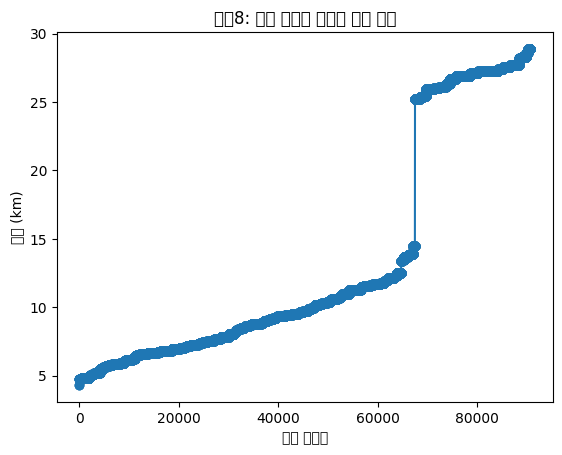

c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\chaeh\anaconda3\envs\DM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Deja

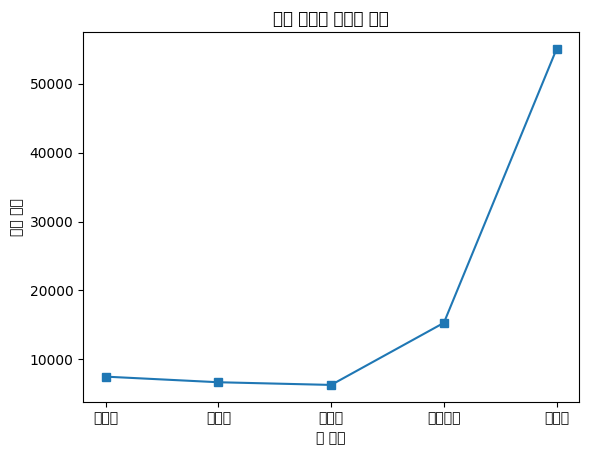

In [9]:
# 실행

result_df = add_train_distance(
    input_path = INPUT_PATH,
    api_key    = KAKAO_API_KEY,
    encoding   = ENCODING
)
plot_distribution(result_df)